# **MÓDULO 27 - Projeto de Doenças Cardiovasculares - Regressão Logística**


Assim como na aula que trabalhamos com uma base de dados nova, com um contexto de modelo de propensão a compra de carros, para a atividade de vocês achei interessante trazer também novos desafios.

Nessa tarefa iremos construir um modelo que nos ajude a prever doenças cardiovasculares, a base contém dados reais.

age - idade dos pacientes

gender - genero (2 mulheres) (1 homens)

height - altura dos pacientes

weight - peso dos pacientes

gluc - glicose

smoke - fumante (1) não fumante (0)

alco - consume alcool (1) não consome (0)

active - realiza atividades fisicas (1) não realiza (0)

cardio_disease - tem doença cardio (1) não tem (0) - Variável target


Seu objetivo é utilizar esses dados históricos dos pacientes e construir um bom modelo de regressão capaz de indicar se novos pacientes estão propensos a doenças cariovasculares ou não.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as px
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report
import plotly.express as px
import numpy as np

# 1) Comece carregando e tratando a base de dados.
Assim como na aula essa nova base não passou por pré processamento nenhum então nessa etapa, carrega os dados, verifique os tipos de dados, verifique se temos dados faltantes e outliers.
Quando necessário realize o tratamento.


In [3]:
base = pd.read_csv("CARDIO_BASE.csv", delimiter=';')
base

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
0,50,2,168,62,1,1,0,0,1,0
1,55,1,156,85,3,1,0,0,1,1
2,52,1,165,64,3,1,0,0,0,1
3,48,2,169,82,1,1,0,0,1,1
4,48,1,156,56,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
9995,56,1,166,65,1,1,0,0,0,0
9996,50,1,160,93,2,1,0,0,1,1
9997,40,1,158,66,2,2,0,0,1,0
9998,50,1,168,70,3,1,0,0,1,1


In [34]:
base['gluc'].unique()

array([1, 2, 3])

In [19]:
base.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             10000 non-null  int64
 1   gender          10000 non-null  int64
 2   height          10000 non-null  int64
 3   weight          10000 non-null  str  
 4   cholesterol     10000 non-null  int64
 5   gluc            10000 non-null  int64
 6   smoke           10000 non-null  int64
 7   alco            10000 non-null  int64
 8   active          10000 non-null  int64
 9   cardio_disease  10000 non-null  int64
dtypes: int64(9), str(1)
memory usage: 781.4 KB


A coluna 'weight' está como string, mas se trata de uma coluna numérica, sendo necessária fazer a transformação do tipo de dado. Ela foi analisada e observou-se a presença de  ',' e  foi realizada a troca para posterior transformação de dados. 

In [4]:
#Substituição da vírgula por ponto para posterior transformação em float.
base['weight'] = base['weight'].str.replace(',', '.', regex=False)

In [5]:
base['weight'] = base['weight'].astype(float)

In [22]:
#Verificação de dados faltantes.
(base.isnull().sum()) / len(base) * 100

age               0.0
gender            0.0
height            0.0
weight            0.0
cholesterol       0.0
gluc              0.0
smoke             0.0
alco              0.0
active            0.0
cardio_disease    0.0
dtype: float64

Não há presença de dados faltantes.

In [24]:
#Verificação de Outliers.
base.describe()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,53.288300,1.345400,164.308200,74.303710,1.365000,1.222200,0.089000,0.053700,0.797200,0.503100
std,6.796234,0.475522,8.178796,14.566353,0.677658,0.565561,0.284758,0.225436,0.402105,0.500015
min,30.000000,1.000000,70.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
75%,58.000000,2.000000,170.000000,82.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,250.000000,200.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


A coluna que apresentou divergências mais elevadas foi 'weight' com valor máximo bem distante da média e da mediana. Assim como 'height', o que implica a presença de possíveis Outliers, mas também pode estar relacionado com as distribuição geral dos dados. 

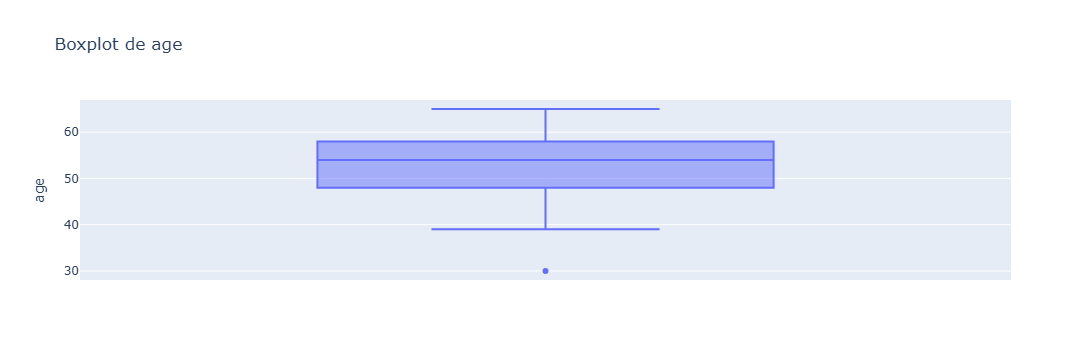

In [6]:
fig = px.box(base, y='age', title='Boxplot de age')
fig.show()

In [10]:
#Cruzamento de variáveis
base.sort_values('age', ascending=True)[
    ['age', 'gender', 'height', 'weight']
].head(10)

,age,gender,height,weight
6219,30,1,175,59.0
7816,39,2,178,85.0
6168,39,2,160,65.0
7662,39,1,156,69.0
5738,39,2,172,81.0
3754,39,1,153,70.0
2535,39,1,152,67.0
5984,39,2,165,65.0
525,39,1,170,67.0
3217,39,2,169,113.0


Na coluna 'age' há a presença de um Outlier, porém é um valor totalmente plausível, portanto escolhido deixá-lo. 
Além disso a coluna 'age' tem uma distribuição mais normal, com os dados concentrados mais próximos a mediana. 

In [23]:
base['gender'].value_counts(normalize=True) * 100

gender
1    65.491688
2    34.508312
Name: proportion, dtype: float64

Na base há mais homens (65%) que mulheres (34%).

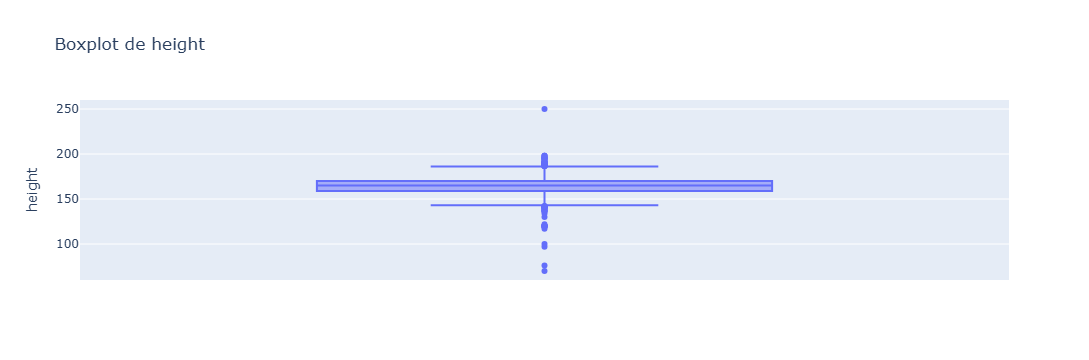

In [31]:
#Variável height
fig = px.box(base, y='height', title='Boxplot de height')
fig.show()

In [17]:
#Aplicando filtro para análise de Outlier
base_filtrada = base[(base['height'] > 200) & (base['height'] < 260)]
base_filtrada.head(50)

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
6486,58,1,250,86.0,3,1,0,0,1,1


In [39]:
#Verificando porcentagem dos valores acima de upper fence.
print("Porcentagem de Registros onde height > 186",
      (len(base[base['height'] > 186]) / len(base)) * 100)

Porcentagem de Registros onde Valor_Aluguel > 186 0.43


In [40]:
#Verificando porcentagem dos valores abaixo de lower fence.
print("Porcentagem de Registros onde height < 143",
      (len(base[base['height'] < 143]) / len(base)) * 100)

Porcentagem de Registros onde height < 143 0.31


In [7]:
#Aplicando filtro para análise de Outlier
base_filtrada = base[(base['height'] > 69) & (base['height'] < 120)]
base_filtrada.head(60)

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
224,60,2,76,55.0,1,1,0,0,1,0
3420,40,1,100,70.0,1,1,0,0,1,0
7116,56,2,117,78.0,1,1,1,0,1,1
7598,40,2,70,72.0,1,1,0,0,1,0
8171,48,2,97,170.0,1,1,1,0,1,1
8677,54,2,119,89.0,1,1,0,0,1,1


Na coluna 'height' há valores muito extremos. Há um valor de 250 (que acredito ser em centímetros relacionado a altura do indivíduo), e valores bem mais baixos com 100, ou 70, que aparentam ser erros de digitação, portanto optei por excluí-los da base, por se tratar de poucos dados e de uma base grande. 

In [6]:
#Excluíndo valores abaixo de 120
base.drop(base[base["height"] < 120].index, inplace=True)

In [7]:
base.drop(base[base["height"] > 249].index, inplace=True)

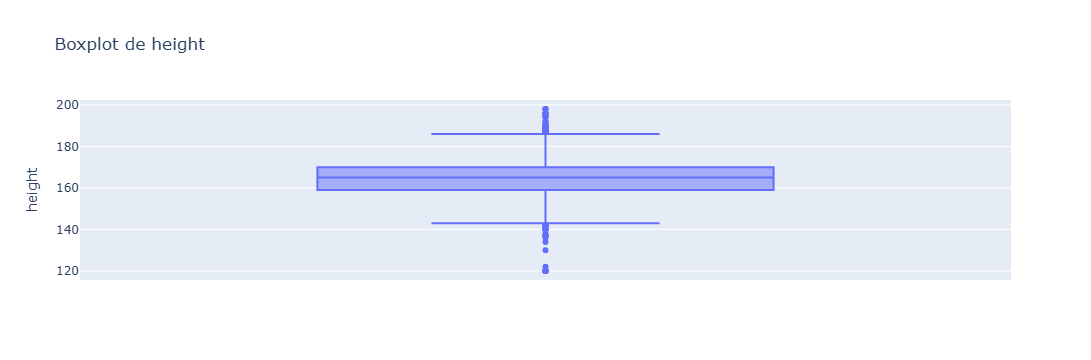

In [8]:
fig = px.box(base, y='height', title='Boxplot de height')
fig.show()

Dados extremos (que aparentavam erro de digitação) foram excluídos. A distribuição dessa coluna é mais normal, com os dados próximos a mediana.

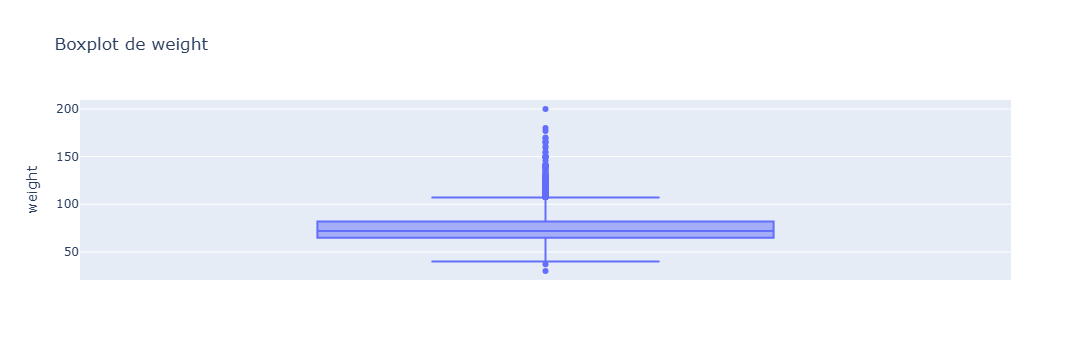

In [27]:
#Plotando box plot de 'weight'
fig = px.box(base, y='weight', title='Boxplot de weight')
fig.show()

In [70]:
#Verificando porcentagem dos valores acima de upper fence.
print("Porcentagem de Registros onde weight > 186")
      (len(base[base['weight'] > 107]) / len(base)) * 100)

Porcentagem de Registros onde weight > 186 2.45


Há a presença de Outliers aqui, mas pelo observado parecem dados reias, portanto resolvi deixá-los. 

In [37]:
base

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
0,50,2,168,62.0,1,1,0,0,1,0
1,55,1,156,85.0,3,1,0,0,1,1
2,52,1,165,64.0,3,1,0,0,0,1
3,48,2,169,82.0,1,1,0,0,1,1
4,48,1,156,56.0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
9995,56,1,166,65.0,1,1,0,0,0,0
9996,50,1,160,93.0,2,1,0,0,1,1
9997,40,1,158,66.0,2,2,0,0,1,0
9998,50,1,168,70.0,3,1,0,0,1,1


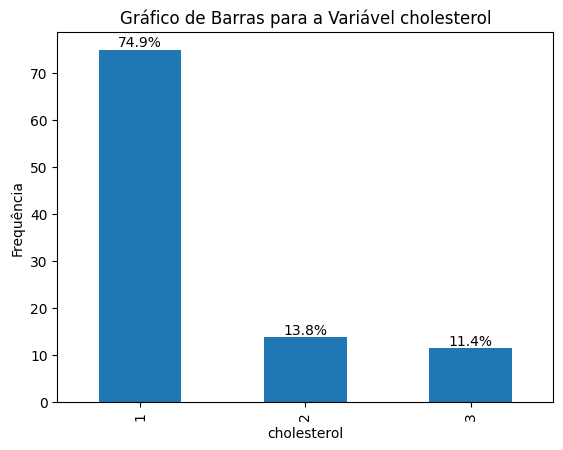

In [49]:
contagem_c_s = base['cholesterol'].value_counts()
porcentagem_c_s = (contagem_c_s / contagem_c_s.sum()) * 100

ax = porcentagem_c_s.plot(kind='bar')
plt.title('Gráfico de Barras para a Variável cholesterol')
plt.xlabel('cholesterol')
plt.ylabel('Frequência')

ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.show()

O valor que aparece como maior índice na coluna 'Cholesterol' é o valor 1 com 74.9%, seguido de 2 com 13.8% e 3 com 11.4%. Mostrando que a maioria dos indivíduos possuem um colesterol normal. 

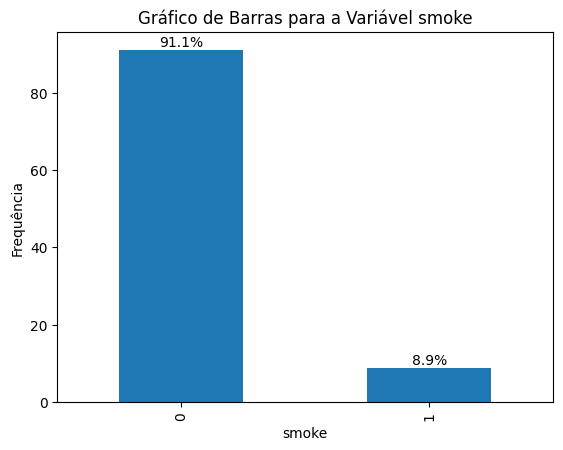

In [48]:
contagem_c_s = base['smoke'].value_counts()
porcentagem_c_s = (contagem_c_s / contagem_c_s.sum()) * 100

ax = porcentagem_c_s.plot(kind='bar')
plt.title('Gráfico de Barras para a Variável smoke')
plt.xlabel('smoke')
plt.ylabel('Frequência')

ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.show()

91.1% dos indivíduos não fumam. 

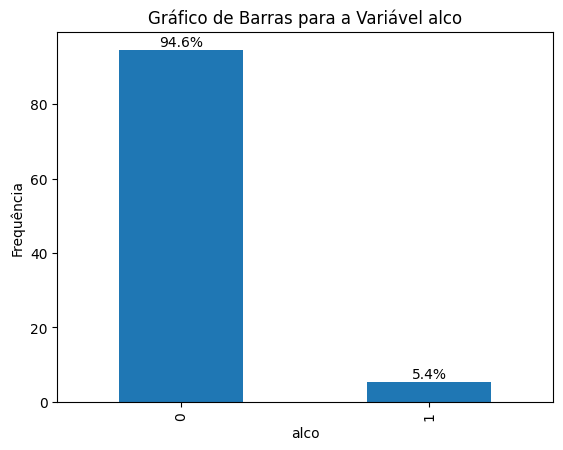

In [45]:
contagem_c_s = base['alco'].value_counts()
porcentagem_c_s = (contagem_c_s / contagem_c_s.sum()) * 100

ax = porcentagem_c_s.plot(kind='bar')
plt.title('Gráfico de Barras para a Variável alco')
plt.xlabel('alco')
plt.ylabel('Frequência')

ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.show()

94.6% dos indivíduos não consomem álcool.

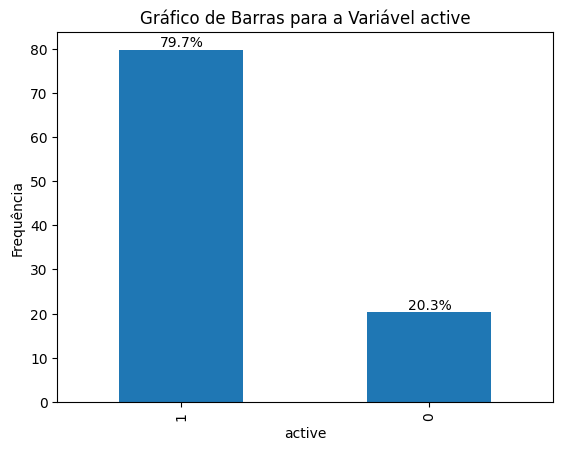

In [47]:
contagem_c_s = base['active'].value_counts()
porcentagem_c_s = (contagem_c_s / contagem_c_s.sum()) * 100

ax = porcentagem_c_s.plot(kind='bar')
plt.title('Gráfico de Barras para a Variável active')
plt.xlabel('active')
plt.ylabel('Frequência')

ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.show()

79.7% dos indivíduos realizam atividades físicas. 

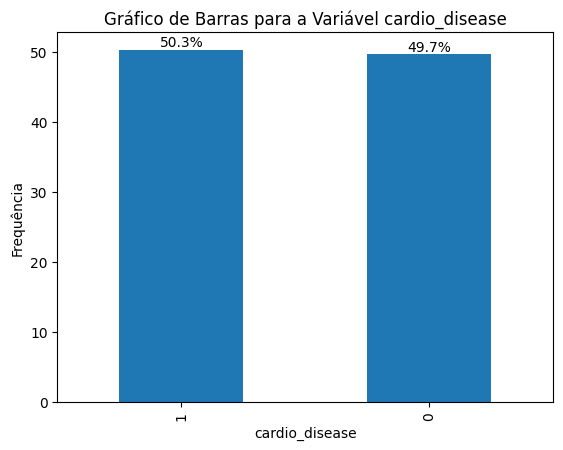

In [50]:
contagem_c_s = base['cardio_disease'].value_counts()
porcentagem_c_s = (contagem_c_s / contagem_c_s.sum()) * 100

ax = porcentagem_c_s.plot(kind='bar')
plt.title('Gráfico de Barras para a Variável cardio_disease')
plt.xlabel('cardio_disease')
plt.ylabel('Frequência')

ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.show()

50.3% dos indivíduos apresentam problemas cardíacos enquanto que 49.7% não. 

# 2) Agora é hora de explorar os dados com uma análise bem completa.
Plote pelo menos 3 gráficos analisando o comportamento da variável cardio com outras variaveis da sua preferência (análise bivariada). Não se esqueça de trazer insights acerca do analisado.


**ANÁLISE BIVARIADA**

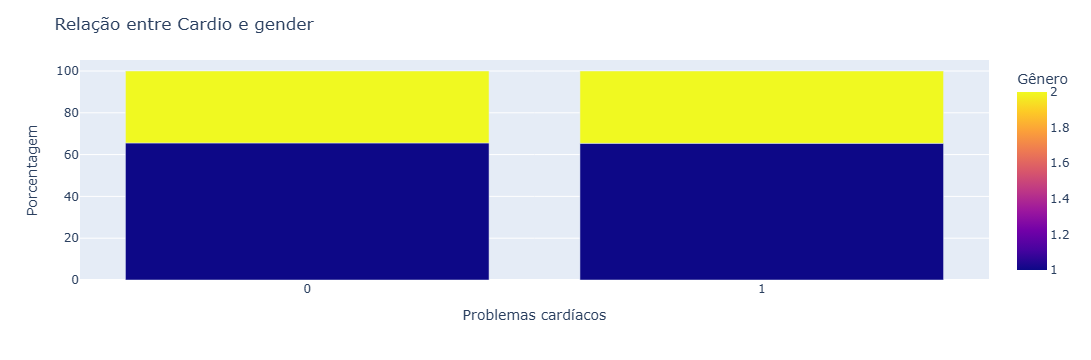

In [53]:
# Calcular a porcentagem de cada categoria
base_grouped = base.groupby(['cardio_disease', 'gender']).size().reset_index(name='count')
total_por_churn = base_grouped.groupby('cardio_disease')['count'].transform('sum')
base_grouped['percent'] = (base_grouped['count'] / total_por_churn) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(base_grouped, x='cardio_disease', y='percent', color='gender', barmode='stack',
             labels={'cardio_disease': 'Problemas cardíacos', 'percent': 'Porcentagem', 'gender': 'Gênero'})

fig.update_layout(title='Relação entre Cardio e gender',
                  yaxis_title='Porcentagem',
                  legend_title='Problemas cardíacos')
fig.show()

De todos que tem problemas cardíacos 65.38% são homens, e 34.61% são mulheres. E dos que não tem 65.58% são homens e  34.41 são mulheres. De modo geral a base é composta 65% pelo gênero masculino, e no gráfico acima os valores de 0 e 1 estão bem equilibrados para cada gênero. Pode haver mais homens com problemas cardíacos pois na base há mais homens.

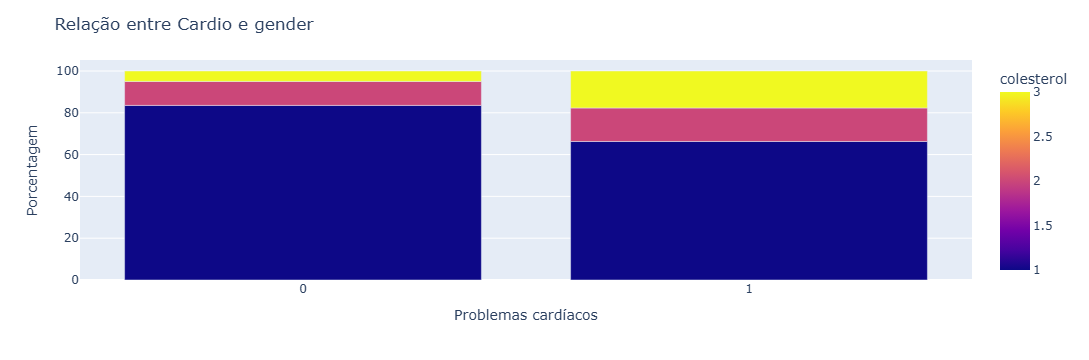

In [56]:
# Calcular a porcentagem de cada categoria
base_grouped = base.groupby(['cardio_disease', 'cholesterol']).size().reset_index(name='count')
total_por_churn = base_grouped.groupby('cardio_disease')['count'].transform('sum')
base_grouped['percent'] = (base_grouped['count'] / total_por_churn) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(base_grouped, x='cardio_disease', y='percent', color='cholesterol', barmode='stack',
             labels={'cardio_disease': 'Problemas cardíacos', 'percent': 'Porcentagem', 'cholesterol': 'colesterol'})

fig.update_layout(title='Relação entre Cardio e gender',
                  yaxis_title='Porcentagem',
                  legend_title='Problemas cardíacos')
fig.show()

Pessoas com problemas cardíacos apresentam maior porcentagem de colesterol dos tipos 2 (acima do normal) com 17.6% e 3 (muito acima do normal) com 16%. Comparado as que não possuem problemas cardíacos que apresentam 11.4% do tipo 2 e 4.9% do tipo 3. 

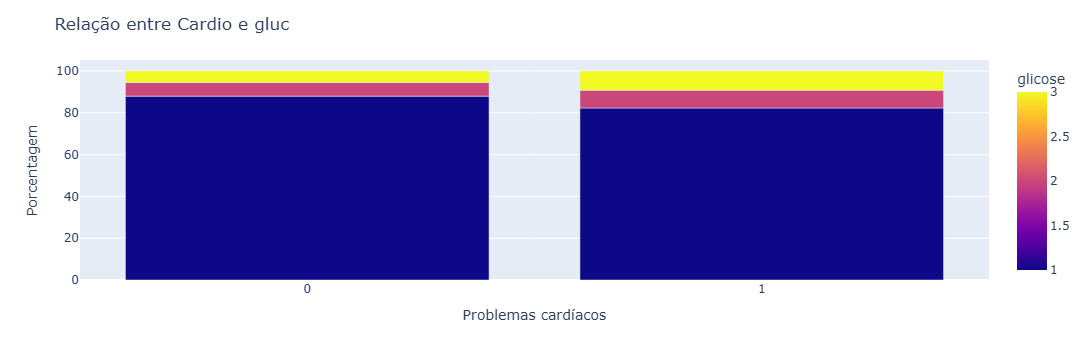

In [57]:
# Calcular a porcentagem de cada categoria
base_grouped = base.groupby(['cardio_disease', 'gluc']).size().reset_index(name='count')
total_por_churn = base_grouped.groupby('cardio_disease')['count'].transform('sum')
base_grouped['percent'] = (base_grouped['count'] / total_por_churn) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(base_grouped, x='cardio_disease', y='percent', color='gluc', barmode='stack',
             labels={'cardio_disease': 'Problemas cardíacos', 'percent': 'Porcentagem', 'gluc': 'glicose'})

fig.update_layout(title='Relação entre Cardio e gluc',
                  yaxis_title='Porcentagem',
                  legend_title='Problemas cardíacos')
fig.show()

82% das pessoas com problemas cardíacos tem glicose normal. 

<Axes: xlabel='cholesterol', ylabel='age'>

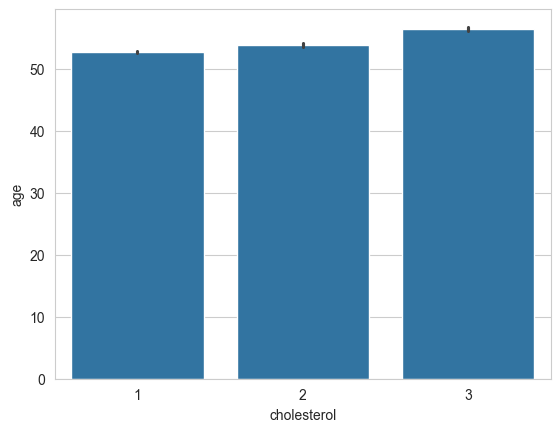

In [69]:
sns.barplot(x="cholesterol", y="age", data=base)

<Axes: xlabel='cholesterol', ylabel='age'>

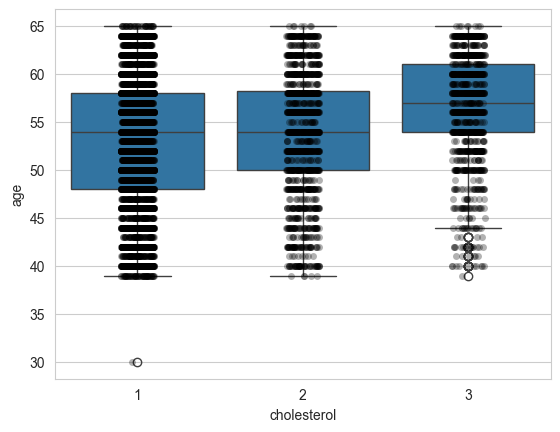

In [70]:
sns.boxplot(x="cholesterol", y="age", data=base)
sns.stripplot(x="cholesterol", y="age", data=base, color="black", alpha=0.3)

Pessoas mais velhas tendem a ter um colesterol mais alto. Sendo a porcentagem de pessoas com alto colesterol 11.4% (como visto em um gráfico anterior).  

<Axes: xlabel='cardio_disease', ylabel='age'>

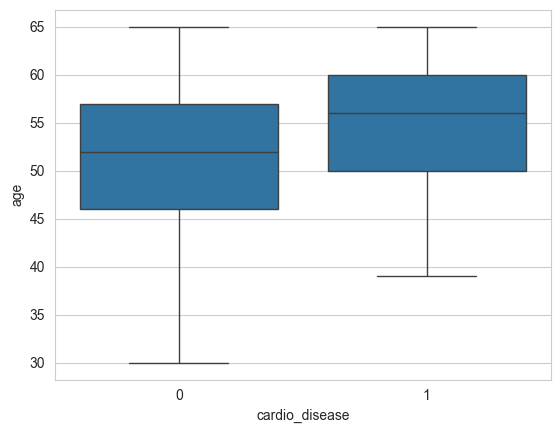

In [17]:
sns.boxplot(x="cardio_disease", y="age", data=base)

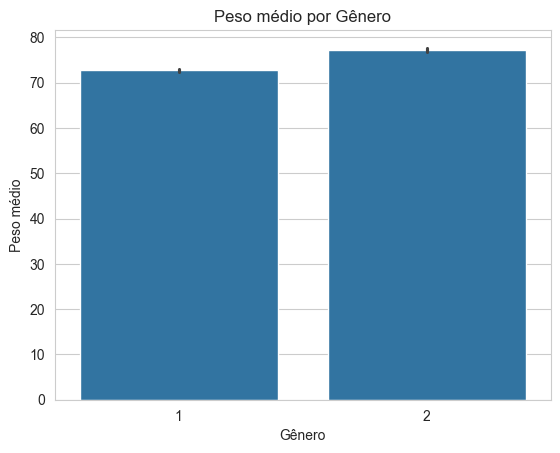

In [21]:
sns.barplot(x='gender', y='weight', data=base)

plt.xlabel('Gênero')
plt.ylabel('Peso médio')
plt.title('Peso médio por Gênero')

plt.show()

In [22]:
base.groupby('gender')['weight'].mean()

gender
1    72.723013
2    77.273905
Name: weight, dtype: float64

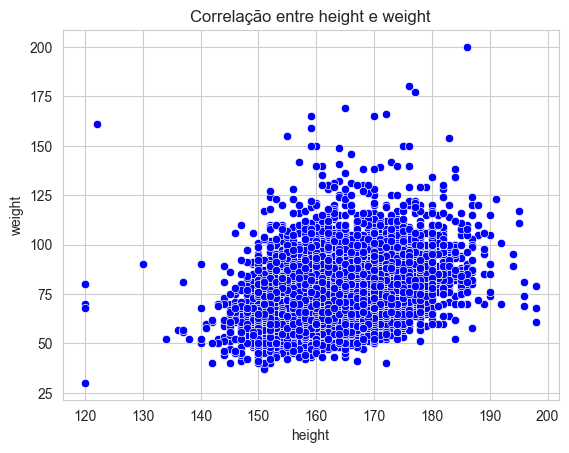

In [16]:
#Correlação  entre Metragem e Valor de Condomínio
sns.set_style("whitegrid")

sns.scatterplot(
    data=base,
    x='height',
    y='weight',
    color='blue'
)

plt.title('Correlação entre height e weight')
plt.show()

Parecem ter uma correlação positiva.

In [21]:
base

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
0,50,2,168,62.0,1,1,0,0,1,0
1,55,1,156,85.0,3,1,0,0,1,1
2,52,1,165,64.0,3,1,0,0,0,1
3,48,2,169,82.0,1,1,0,0,1,1
4,48,1,156,56.0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
9995,56,1,166,65.0,1,1,0,0,0,0
9996,50,1,160,93.0,2,1,0,0,1,1
9997,40,1,158,66.0,2,2,0,0,1,0
9998,50,1,168,70.0,3,1,0,0,1,1


# 3) Nessa etapa você deve trazer a matriz de correlação e apontar insights acerca das variáveis com um relacionamento mais forte entre si.



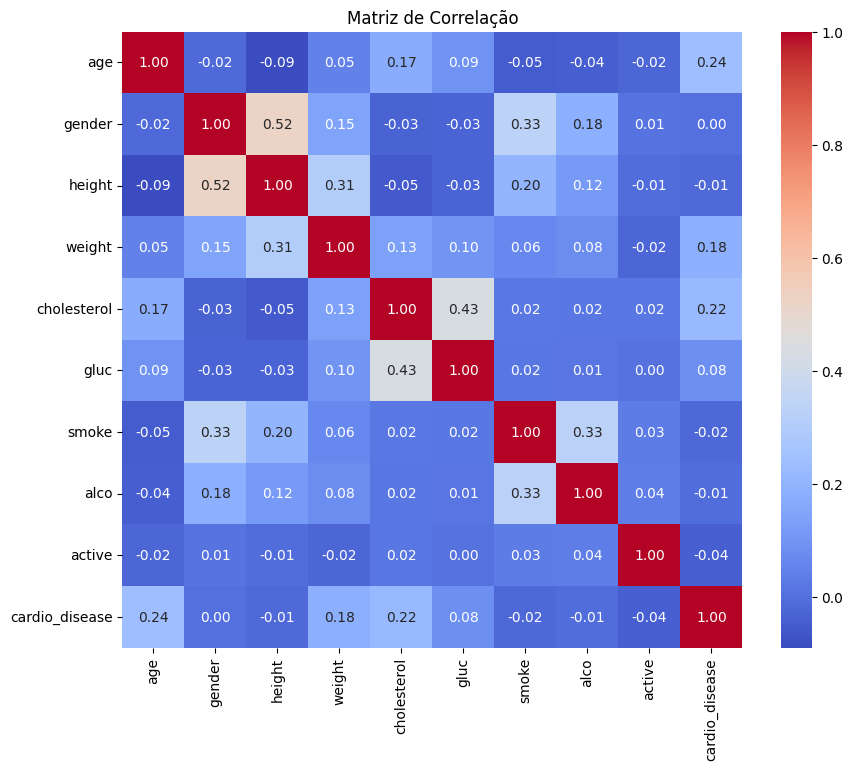

In [22]:
#Gráfico de correlação entre todas as variáveis.
corr_matriz = base.select_dtypes(include=['number']).corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matriz, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

Pelo observado na Matriz de Correlação as variáveis que apresentam maior positiva correlação com a Target (cardio_disease) são 'age' 'cholesterol' e 'weight'. Outras variáveis apresentam correlação positivas maiores como 'height' e 'gender' com 0.52, seguida de 'gluc' e 'cholesterol' com 0.43, 'gender' e 'smoke' com 0.33 e 'smoke' e 'alco' com 0.33.

# 4) Essa é a sua última etapa pré modelo. Você deve:

A) Separar a base em treino e teste.

B) Você considera que essa base precisa que os dados sejam padronizados? Se sim, porque? Se acredita que devem, então realize essa etapa.

C) Verifique se os dados estão balanceados, se não, faça o balanceamento.


D) Visualize as bases de treino, teste (X E Y) e verifique se está tudo adequado.

In [9]:
# Separar os dados em features (X) e o alvo (y)
X = base.drop('cardio_disease', axis=1) #Separando X - Todas variáveis exceto cardio_disease
y = base['cardio_disease'] #Separando Y (Apenas variavel cardio_disease)

In [10]:
from sklearn.model_selection import train_test_split

#Separando treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [11]:
y_test

3124    0
1442    1
6284    1
39      1
4096    1
       ..
6685    1
4384    0
1102    0
9537    1
7641    1
Name: cardio_disease, Length: 2499, dtype: int64

In [12]:
X_test

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active
3124,52,1,157,64.0,1,2,0,0,1
1442,60,1,162,90.0,2,1,0,0,1
6284,56,2,164,69.0,1,1,1,0,0
39,50,1,165,70.0,1,1,0,0,1
4096,60,1,150,47.0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...
6685,56,1,165,68.0,3,1,0,0,1
4384,48,2,175,91.0,1,1,0,0,0
1102,64,1,172,85.0,1,1,0,0,1
9537,54,1,165,82.0,1,1,0,0,1


In [13]:
# Padronização: Inicializar StandardScaler
sc = StandardScaler()

# Ajustando e transformando os dados de treino
X_train = sc.fit_transform(X_train)

# Transformando os dados de teste usando os parâmetros aprendidos dos dados de treino
X_test = sc.transform(X_test)

Fiz a padronização nos dados pois há colunas com valores em escalas distantes, padronizei para ficar melhor para o modelo. 

In [14]:
#Verificando se a target está desbalanceada 

base['cardio_disease'].value_counts()

cardio_disease
1    5027
0    4966
Name: count, dtype: int64

In [35]:
# 2. Proporção
base['cardio_disease'].value_counts(normalize=True) * 100

cardio_disease
1    50.305214
0    49.694786
Name: proportion, dtype: float64

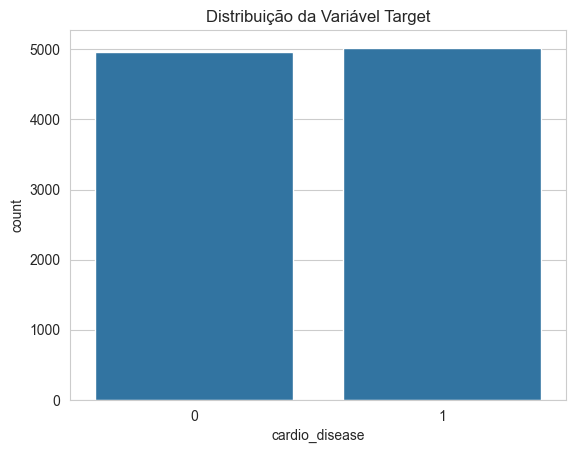

In [36]:
# 3. Visualização
sns.countplot(x='cardio_disease', data=base)
plt.title('Distribuição da Variável Target')
plt.show()

A variável parece está bem balanceada, portanto não há necessidade de mexer nela. 

In [15]:
X_train

array([[-0.91731168, -0.7254467 ,  0.21365058, ..., -0.31025009,
        -0.23777008, -1.95747834],
       [ 0.55370042, -0.7254467 ,  0.08718159, ..., -0.31025009,
        -0.23777008, -1.95747834],
       [-2.09412137,  1.37846103,  1.09893353, ..., -0.31025009,
        -0.23777008,  0.51086133],
       ...,
       [-0.18180563, -0.7254467 , -0.29222539, ..., -0.31025009,
        -0.23777008,  0.51086133],
       [ 0.11239679, -0.7254467 ,  0.08718159, ..., -0.31025009,
        -0.23777008,  0.51086133],
       [ 0.70080163, -0.7254467 , -1.05103935, ..., -0.31025009,
        -0.23777008,  0.51086133]], shape=(7494, 9))

In [40]:
y_train

5509    1
9892    0
118     0
2023    1
9885    1
       ..
5736    0
5193    0
5392    0
861     0
7274    0
Name: cardio_disease, Length: 7494, dtype: int64

In [16]:
X_test

array([[-0.18180563, -0.7254467 , -0.92457035, ..., -0.31025009,
        -0.23777008,  0.51086133],
       [ 0.99500405, -0.7254467 , -0.29222539, ..., -0.31025009,
        -0.23777008,  0.51086133],
       [ 0.40659921,  1.37846103, -0.03928741, ...,  3.22320613,
        -0.23777008, -1.95747834],
       ...,
       [ 1.58340889, -0.7254467 ,  0.97246454, ..., -0.31025009,
        -0.23777008,  0.51086133],
       [ 0.11239679, -0.7254467 ,  0.08718159, ..., -0.31025009,
        -0.23777008,  0.51086133],
       [ 0.70080163,  1.37846103,  1.6048095 , ..., -0.31025009,
        -0.23777008,  0.51086133]], shape=(2499, 9))

In [41]:
y_test

3124    0
1442    1
6284    1
39      1
4096    1
       ..
6685    1
4384    0
1102    0
9537    1
7641    1
Name: cardio_disease, Length: 2499, dtype: int64

# 5) Realize a etapa de treinamento do modelo:

A) Faça o treinamento do modelo.

B) Traga o intercept e os coeficientes.

c) Avalie as métricas do modelo treinado

D) Justifique se te parece que o modelo tem feito boas previsões ou não.

In [17]:
# Utilizaremos a sklearn
from sklearn.linear_model import LogisticRegression

In [20]:
logistic_cardio = LogisticRegression(random_state = 0)

In [21]:
logistic_cardio.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [22]:
logistic_cardio.intercept_

array([0.01890856])

In [23]:
logistic_cardio.coef_

array([[ 0.43360044,  0.03551887, -0.09938262,  0.36950075,  0.40772469,
        -0.08020582, -0.06068503, -0.00644884, -0.10200411]])

In [24]:
previsao = logistic_cardio.predict(X_train)

In [25]:
relatorio = classification_report(y_train, previsao)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.63      0.66      0.65      3738
           1       0.65      0.61      0.63      3756

    accuracy                           0.64      7494
   macro avg       0.64      0.64      0.64      7494
weighted avg       0.64      0.64      0.64      7494



Fiz o teste removendo outras variáveis como gender, height, smoke, alco e active, mas o resultado piorou com o recall descendo para 0.51, e alguns outros testes não mudaram o valor da métricas, então deixei com todas as variáveis pois essa acurácia foi a melhor que encontrei. 

# 6) Teste seu modelo!

A) Aplique o modelo aos dados de teste.

B) Avalie as métricas do modelo treinado

C) Plote o gráfico da curva AUC-ROC e explique o que consegue analisar através do gráfico.

In [66]:
y_pred = logistic_cardio.predict(X_test)

In [67]:
relatorio = classification_report(y_test, y_pred)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.62      0.67      0.64      1228
           1       0.65      0.61      0.63      1271

    accuracy                           0.64      2499
   macro avg       0.64      0.64      0.64      2499
weighted avg       0.64      0.64      0.64      2499



A métrica da acurácia foi semelhante nos dados de treino e teste. Ouve melhoras em algumas métricas e pioras em outras. 

As métricas de precisão e f1 score tiveram pioras, e o recall teve melhora (mas todas essas mudanças foram bem leves).
O modelo está conseguindo generalizar bem para os novos dados adicionados.


In [69]:
fpr, tpr, thresholds = roc_curve(y_test,y_pred)

# Cálculo de AUC
roc_auc = roc_auc_score(y_test, y_pred)
print("AUC: {:.2f}".format(roc_auc))

AUC: 0.64


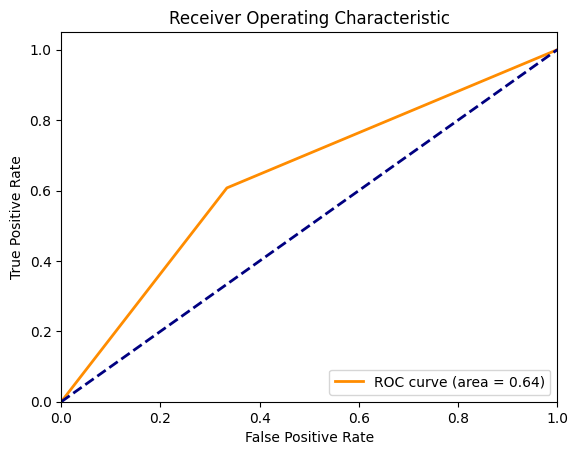

In [70]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

O resultado de AUC foi de 0.64. Esse valor implica que ele consegue fazer previsões melhores que ao acaso, mas possui baixa performance ou "discriminação pobre", o que valida com os dados apresentados na etapa de Análise Exploratório e Matriz de Correlação, onde os dados apresentaram pouca correlação. 

# 7) Explique:

A) Explique com suas palavras regressão logistica.

B) Explique porque a regressão logistica é um modelo de classificação.

C) Explique quais pontos em comum a regressão logistica tem da regressão linear.



A Regressão Logística é um modelo de classificação binária, que é utilizado para prever a probabilidade de um determinado evento ocorrer (sim ou não, 0 ou 1). Esse modelo utiliza variáveis que dão base para a previsão ser feita. Tanto a Regressão Logística quanto a Linear são modelo de Aprendizado Superviosionado que utilizam variáveis independentes para prever a variável target, são sensíveis a escala de dados sendo importante fazer a padronização e o balanceamento adequados para os dados, outro ponto em comum é que para realizar as previsões ambos os modelos utilizam a combinação linear de variáveis independentes. 